images shape: (333, 500, 3)
labels shape: ()


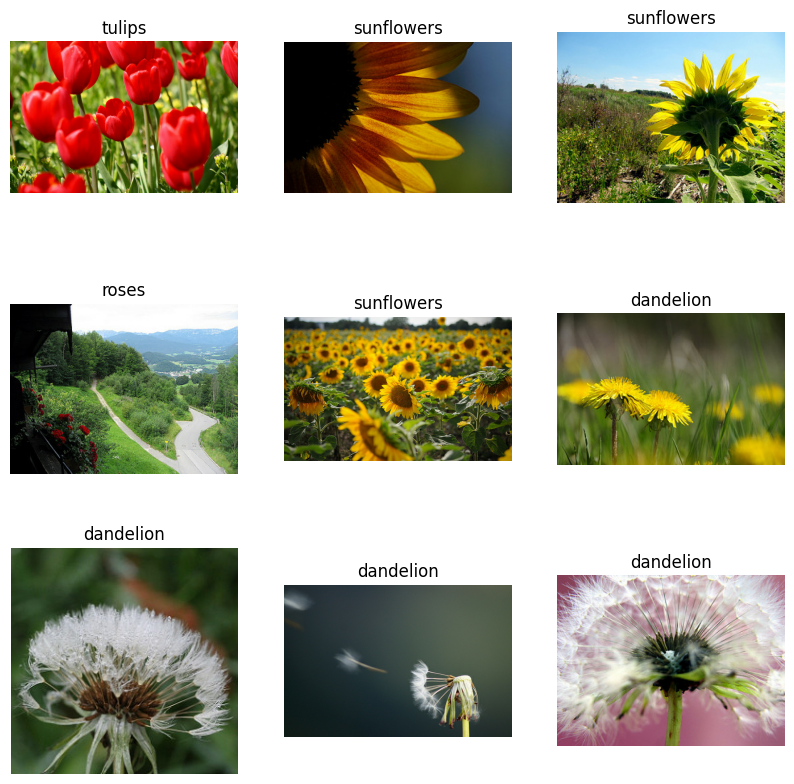

In [1]:
# loading tf_flowers dataset

from tensorflow import keras
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

for images, labels in train_ds.take(1):
    print("images shape:", images.shape)
    print("labels shape:", labels.shape)

class_names = metadata.features['label'].names

plt.figure(figsize=(10,10))
for i, (image, label) in enumerate(train_ds.take(9)):
    plt.subplot(3, 3, i+1)
    plt.imshow(tf.cast(image, tf.uint8).numpy())
    plt.title(class_names[int(label.numpy())])
    plt.axis("off")
plt.show()


images shape: (128, 128, 3)
labels shape: ()


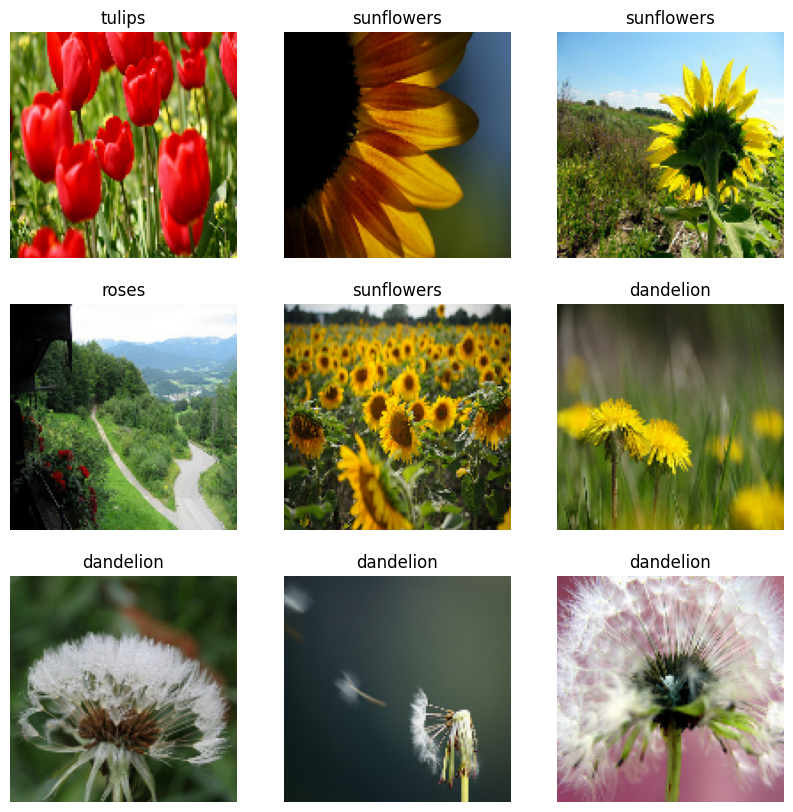

In [2]:
# resize and normalize data

from tensorflow.keras import layers

IMG_SIZE = 128

resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMG_SIZE, IMG_SIZE),
  layers.Rescaling(1./255)
])

train_ds = train_ds.map(lambda x, y: (resize_and_rescale(x), y))
val_ds = val_ds.map(lambda x, y: (resize_and_rescale(x), y))
test_ds = test_ds.map(lambda x, y: (resize_and_rescale(x), y))

for images, labels in train_ds.take(1):
    print("images shape:", images.shape)
    print("labels shape:", labels.shape)

plt.figure(figsize=(10,10))
for i, (image, label) in enumerate(train_ds.take(9)):
    plt.subplot(3, 3, i+1)
    plt.imshow(image.numpy())
    plt.title(class_names[int(label.numpy())])
    plt.axis("off")

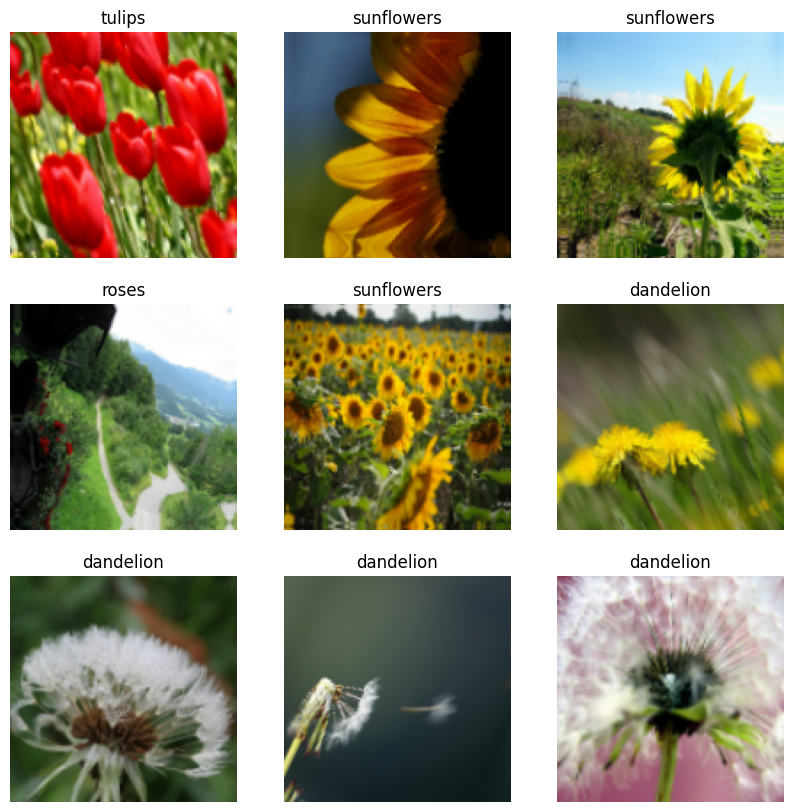

In [3]:
# data augmentation

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])


plt.figure(figsize=(10,10))
for i, (image, label) in enumerate(train_ds.take(9)):
    augmented_image = data_augmentation(image)
    plt.subplot(3, 3, i+1)
    plt.imshow(augmented_image.numpy())
    plt.title(class_names[int(label.numpy())])
    plt.axis("off")

In [4]:
# Making a simple model as the earlier one with 20 hidden layers containing 100 neurons each since nothing else is specified.
# This one is the baseline without any augmentation. Optimizer is adam with default learning rate

import os
import datetime
from tensorflow import keras
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

keras.backend.clear_session()

base_dir = r"C:\Users\nisse\Skola\DIL700\Assignment4.2"


log_dir = os.path.join(
    base_dir, "logs", "flowers_baseline",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

model = tf.keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Flatten(),
    *[layers.Dense(100, activation='relu') for _ in range(20)],
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    train_ds.batch(32),
    validation_data=val_ds.batch(32),
    epochs=100,
    callbacks=[tensorboard_callback, early_stopping_callback]
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - accuracy: 0.2432 - loss: 1.6014 - val_accuracy: 0.2425 - val_loss: 1.5928
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.2956 - loss: 1.5370 - val_accuracy: 0.2398 - val_loss: 1.5657
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.3236 - loss: 1.4912 - val_accuracy: 0.2670 - val_loss: 1.5496
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.3348 - loss: 1.4875 - val_accuracy: 0.3161 - val_loss: 1.4829
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.3304 - loss: 1.4743 - val_accuracy: 0.2970 - val_loss: 1.5084
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.3471 - loss: 1.4652 - val_accuracy: 0.3134 - val_loss: 1.4816
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.3464 - loss: 1.4388 - val_accuracy: 0.2997 - val_loss: 1.4648
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.3607 - loss: 1.4349 - val_accuracy

In [5]:
# doing data augmentation on the training data and running the model again with the same parameters as before

import os
import datetime
from tensorflow import keras
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers

IMG_SIZE = 128

tf.keras.backend.clear_session()

(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

class_names = metadata.features['label'].names

resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMG_SIZE, IMG_SIZE),
  layers.Rescaling(1./255)
])

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

aug_ds = train_ds.map(
  lambda x, y: (resize_and_rescale(x, training=True), y))

batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, shuffle=False, augment=False):
  # Resize and rescale all datasets.
  ds = ds.map(lambda x, y: (resize_and_rescale(x), y), 
              num_parallel_calls=AUTOTUNE)

  if shuffle:
    ds = ds.shuffle(1000)

  # Batch all datasets.
  ds = ds.batch(batch_size)

  # Use data augmentation only on the training set.
  if augment:
    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), 
                num_parallel_calls=AUTOTUNE)

  # Use buffered prefetching on all datasets.
  return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = prepare(train_ds, shuffle=True, augment=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)

# following is the exact same as before except fpr the log_dir and the name of the model

base_dir = r"C:\Users\nisse\Skola\DIL700\Assignment4.2"


log_dir = os.path.join(
    base_dir, "logs", "flowers_augumented",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

model = tf.keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Flatten(),
    *[layers.Dense(100, activation='relu') for _ in range(20)],
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[tensorboard_callback, early_stopping_callback]
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 316ms/step - accuracy: 0.2449 - loss: 1.5948 - val_accuracy: 0.2452 - val_loss: 1.5680
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.2517 - loss: 1.5730 - val_accuracy: 0.2807 - val_loss: 1.5304
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.2405 - loss: 1.5967 - val_accuracy: 0.2425 - val_loss: 1.5948
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.2524 - loss: 1.5993 - val_accuracy: 0.2425 - val_loss: 1.5873
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.2701 - loss: 1.5623 - val_accuracy: 0.3215 - val_loss: 1.5097
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.2984 - loss: 1.5196 - val_accuracy: 0.2943 - val_loss: 1.5174
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.3277 - loss: 1.4838 - val_accuracy: 0.2834 - val_loss: 1.4950
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.3229 - loss: 1.4723 - val_a

The model actually performed worse after augmentation. This probably has more to do with the too deep model then the augmentation since the model not even fits the training data properly.

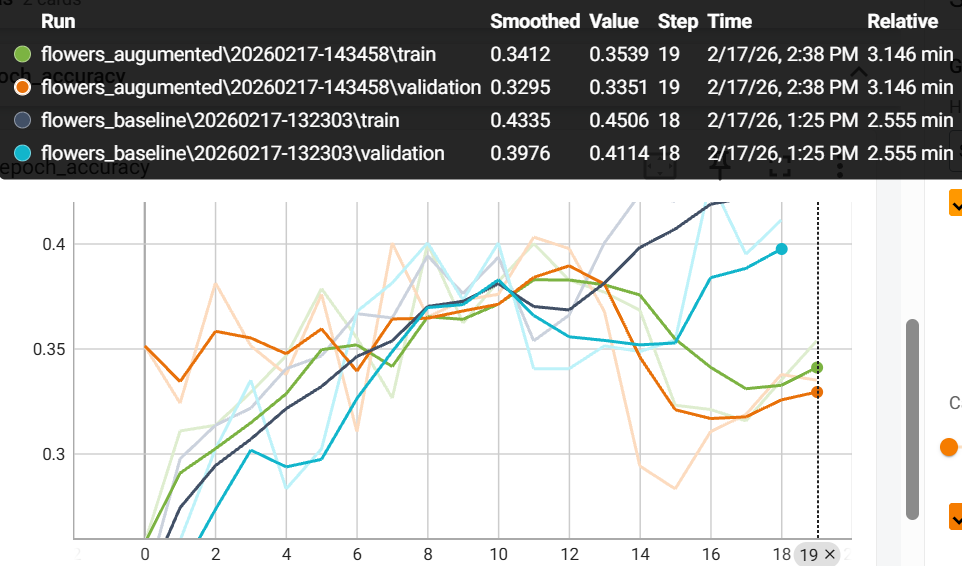

In [6]:
# baseline using better model

# loading tf_flowers dataset

tf.keras.backend.clear_session()

from tensorflow import keras
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

class_names = metadata.features['label'].names

from tensorflow.keras import layers

IMG_SIZE = 128

resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMG_SIZE, IMG_SIZE),
  layers.Rescaling(1./255)
])

train_ds = train_ds.map(lambda x, y: (resize_and_rescale(x), y))
val_ds = val_ds.map(lambda x, y: (resize_and_rescale(x), y))
test_ds = test_ds.map(lambda x, y: (resize_and_rescale(x), y))

base_dir = r"C:\Users\nisse\Skola\DIL700\Assignment4.2"


log_dir = os.path.join(
    base_dir, "logs", "flowers_baseline2",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

model = tf.keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    train_ds.batch(32),
    validation_data=val_ds.batch(32),
    epochs=200,
    callbacks=[tensorboard_callback, early_stopping_callback]
)

Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 209ms/step - accuracy: 0.3280 - loss: 1.4860 - val_accuracy: 0.4278 - val_loss: 1.3483
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step - accuracy: 0.4407 - loss: 1.2696 - val_accuracy: 0.5041 - val_loss: 1.2437
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - accuracy: 0.4928 - loss: 1.1967 - val_accuracy: 0.5286 - val_loss: 1.1878
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 208ms/step - accuracy: 0.5245 - loss: 1.1464 - val_accuracy: 0.5559 - val_loss: 1.1425
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 234ms/step - accuracy: 0.5477 - loss: 1.1049 - val_accuracy: 0.6076 - val_loss: 1.1020
Epoch 6/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 79s 636ms/step - accuracy: 0.5712 - loss: 1.0695 - val_accuracy: 0.6267 - val_loss: 1.0631
Epoch 7/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 241ms/step - accuracy: 0.5841 - loss: 1.0416 - val_accuracy: 0.6376 - val_loss: 1.0346
Epoch 8/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - accuracy: 0.5937 - loss: 1.0186 - 

In [7]:
# doing data augmentation on the training data and running the model again with the same parameters as before

import os
import datetime
from tensorflow import keras
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers

IMG_SIZE = 128

tf.keras.backend.clear_session()

(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

class_names = metadata.features['label'].names

resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMG_SIZE, IMG_SIZE),
  layers.Rescaling(1./255)
])

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.05), # decreased this one since flowers rarely grow sideways 
  layers.RandomZoom(0.1),
])

aug_ds = train_ds.map(
  lambda x, y: (resize_and_rescale(x, training=True), y))

batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, shuffle=False, augment=False):
  # Resize and rescale all datasets.
  ds = ds.map(lambda x, y: (resize_and_rescale(x), y), 
              num_parallel_calls=AUTOTUNE)

  if shuffle:
    ds = ds.shuffle(1000)

  # Use data augmentation only on the training set.
  if augment:
    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), 
                num_parallel_calls=AUTOTUNE)
  
    # Batch all datasets.
  ds = ds.batch(batch_size)

  # Use buffered prefetching on all datasets.
  return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = prepare(train_ds, shuffle=True, augment=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)

# following is basically the same model but with some changes like patience, and the name of the log dir

base_dir = r"C:\Users\nisse\Skola\DIL700\Assignment4.2"


log_dir = os.path.join(
    base_dir, "logs", "flowers_augumented2",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

model = tf.keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # decreased learning rate since the model is more complex and we are doing data augmentation which should make it harder to learn
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=400,
    callbacks=[tensorboard_callback, early_stopping_callback]
)

Epoch 1/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 74s 710ms/step - accuracy: 0.2766 - loss: 1.5948 - val_accuracy: 0.4169 - val_loss: 1.5716
Epoch 2/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 256ms/step - accuracy: 0.3682 - loss: 1.5602 - val_accuracy: 0.4550 - val_loss: 1.5162
Epoch 3/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 238ms/step - accuracy: 0.3934 - loss: 1.4977 - val_accuracy: 0.4714 - val_loss: 1.4417
Epoch 4/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 234ms/step - accuracy: 0.4091 - loss: 1.4231 - val_accuracy: 0.4278 - val_loss: 1.3795
Epoch 5/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 210ms/step - accuracy: 0.4121 - loss: 1.3658 - val_accuracy: 0.4605 - val_loss: 1.3384
Epoch 6/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.4084 - loss: 1.3292 - val_accuracy: 0.4523 - val_loss: 1.3038
Epoch 7/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.4196 - loss: 1.3037 - val_accuracy: 0.4741 - val_loss: 1.2843
Epoch 8/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 303ms/step - accuracy: 0.4295 - loss: 1.2859 - 

the new models does perform much better and can be used to draw conclusions. then the old ones which can be seen in the corner down to the left. After this picture the learning rate for the augmented data was degreased and the patience of the early stopper was increased

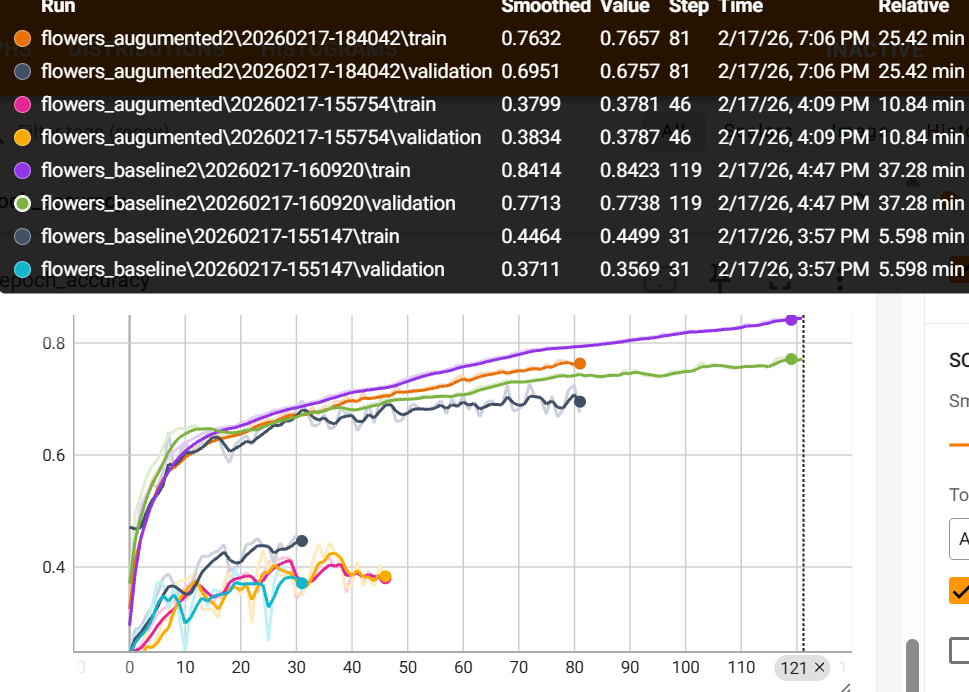

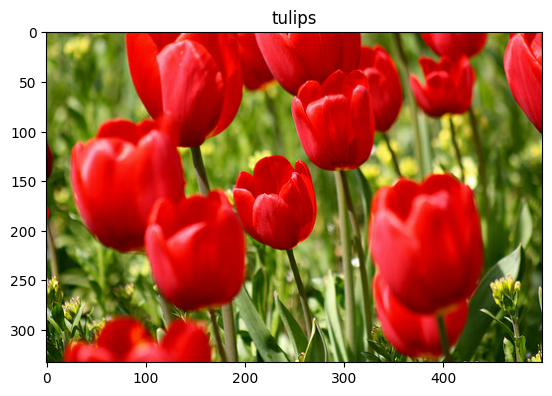

In [8]:
# custom data augmentation

tf.keras.backend.clear_session()

(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

get_label_name = metadata.features['label'].int2str

image, label = next(iter(train_ds))
_ = plt.imshow(image)
_ = plt.title(get_label_name(label))

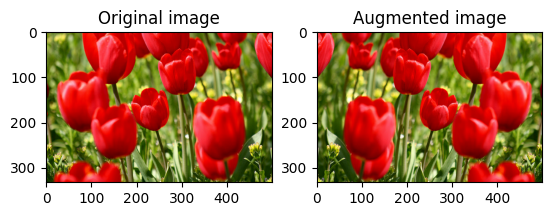

In [9]:
def visualize(original, augmented):
  fig = plt.figure()
  plt.subplot(1,2,1)
  plt.title('Original image')
  plt.imshow(original)

  plt.subplot(1,2,2)
  plt.title('Augmented image')
  plt.imshow(augmented)

flipped = tf.image.flip_left_right(image)
visualize(image, flipped)

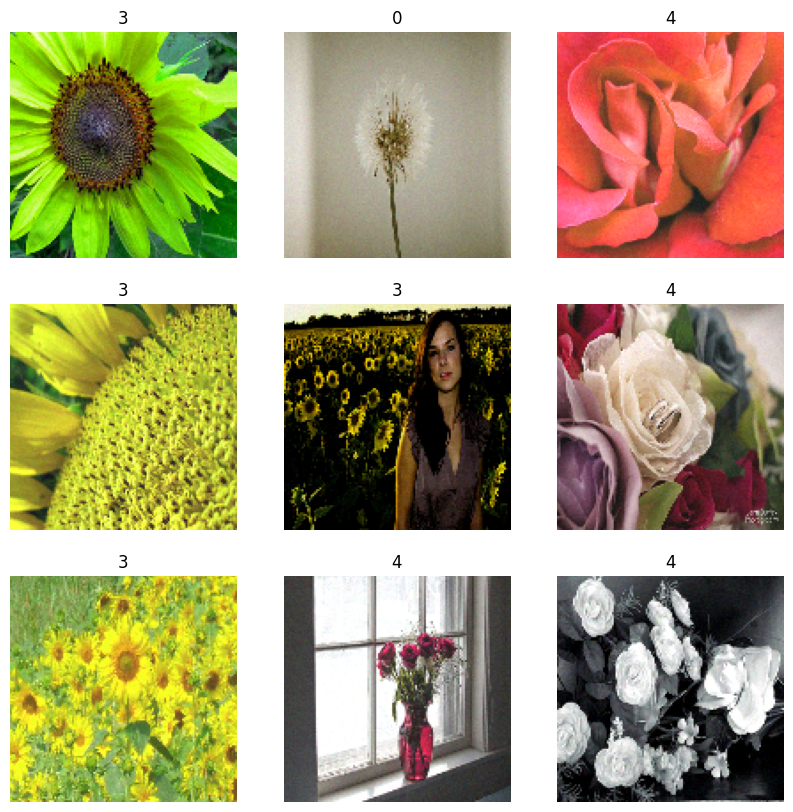

In [10]:
# augmentation pipeline

import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = 128
BATCH = 32

def preprocess_resize_rescale(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def custom_augment_tfimage(image, label):
    # image: float32 [0,1]
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.05)

    # Add mild gaussian noise
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.02, dtype=image.dtype)
    image = image + noise

    # Clip to valid range
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def make_ds(ds, shuffle=False, augment=False):
    ds = ds.map(preprocess_resize_rescale, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    if augment:
        ds = ds.map(custom_augment_tfimage, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE)
    return ds

train_ds_aug = make_ds(train_ds, shuffle=True, augment=True)
# only resizing and rescaling for val and test since we want to evaluate on clean data
val_ds_clean = make_ds(val_ds, shuffle=False, augment=False)
test_ds_clean = make_ds(test_ds, shuffle=False, augment=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for images, labels in train_ds_aug.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy())  # redan float [0,1]
        plt.title(int(labels[i].numpy()))
        plt.axis("off")
plt.show()




In [11]:
base_dir = r"C:\Users\nisse\Skola\DIL700\Assignment4.2"

tf.keras.backend.clear_session()

log_dir = os.path.join(
    base_dir, "logs", "flowers_customaugumented",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

model = tf.keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # decreased learning rate since the model is more complex and we are doing data augmentation which should make it harder to learn
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history = model.fit(
    train_ds_aug,
    validation_data=val_ds_clean,
    epochs=400,
    callbacks=[tensorboard_callback, early_stopping_callback]
)

Epoch 1/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 290ms/step - accuracy: 0.2762 - loss: 1.6007 - val_accuracy: 0.2861 - val_loss: 1.5860
Epoch 2/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 214ms/step - accuracy: 0.2977 - loss: 1.5838 - val_accuracy: 0.3706 - val_loss: 1.5610
Epoch 3/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - accuracy: 0.3430 - loss: 1.5512 - val_accuracy: 0.4550 - val_loss: 1.5053
Epoch 4/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/step - accuracy: 0.3706 - loss: 1.4958 - val_accuracy: 0.4550 - val_loss: 1.4403
Epoch 5/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 181ms/step - accuracy: 0.3954 - loss: 1.4379 - val_accuracy: 0.4087 - val_loss: 1.3889
Epoch 6/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 187ms/step - accuracy: 0.4033 - loss: 1.3963 - val_accuracy: 0.4659 - val_loss: 1.3295
Epoch 7/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 182ms/step - accuracy: 0.4097 - loss: 1.3698 - val_accuracy: 0.4223 - val_loss: 1.3421
Epoch 8/400
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - accuracy: 0.4067 - loss: 1.3532 - 

here we can see all the curves from the lab. The baseline model performs the highest accuracy and trains fast. The keras augmented data does better then before. even if it does not reach the same neighborhood of accuracy as the baseline model it it generalizes quite well. this conclusion we can draw from the fact that there is not much difference between the train and validationcurve.

The really interesting thing here is the curve from the training on the custom augmented data. The validated accuracy is actually higher then the train accuracy. This felt confusing at first but then I realized that the data the model trains on is actually more "broken" or complicated or whatever we want to call it, then the test data. The model generalizes better then the baseline model. the gap between the curves is around 3-4% compared to the baseline models maximum of almost 8%. it should be noted that the training on the augumented fed models took very much longer time. Patience was increased and learning rate was decreased

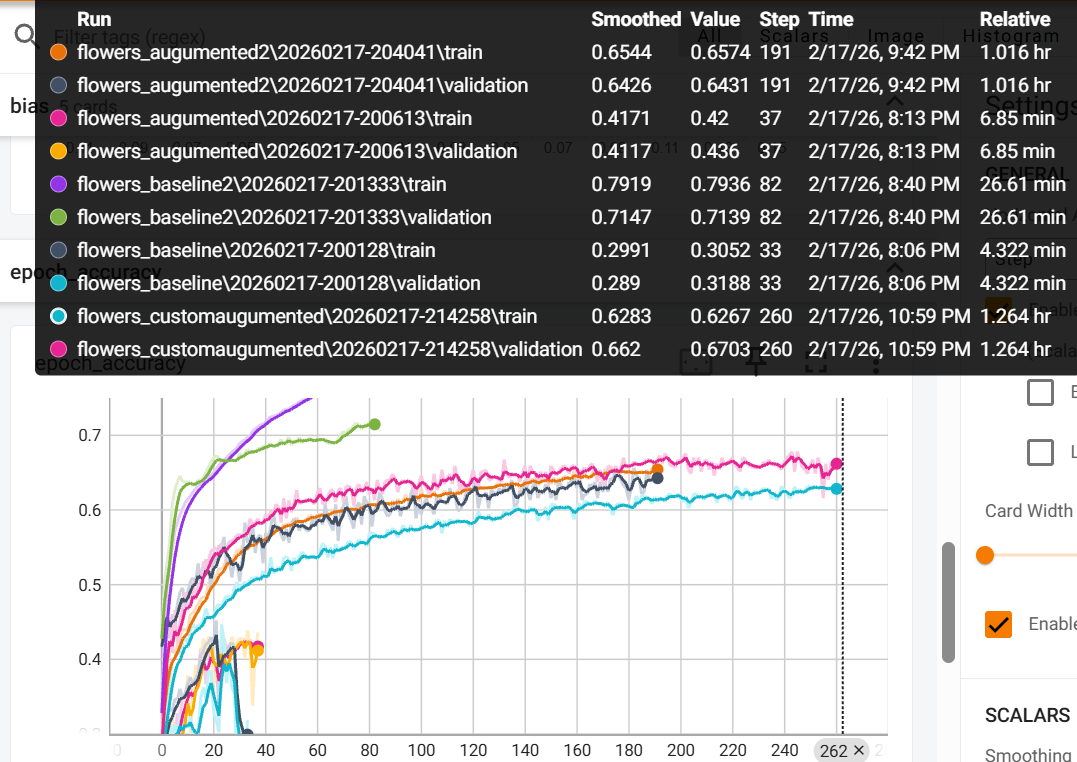